In [1]:
import glob
import json
from functools import partial

import matplotlib.pyplot as plt
import numpy as np


def calc_mode(data, axis=0):
    bins = np.apply_along_axis(
        lambda x: np.bincount(x, minlength=5), axis=axis, arr=data
    )
    # resolve ties randomly by adding a small random number to the counts
    rand_mat = np.random.random_sample(bins.shape)
    bins = bins + rand_mat
    return np.argmax(bins, axis=axis)


mnc_path = "../../examples/output/"
mnc_preds_glob = f"{mnc_path}/*/predictions*_c.npz"
mnc_preds_files = sorted(glob.glob(mnc_preds_glob))
print(mnc_preds_files)
# remove CAP
mnc_preds_files = [f for f in mnc_preds_files if f.split("/")[-2] != "CAP"]
print(mnc_preds_files)

keys_per_run_per_sr = {}
for pred_file in mnc_preds_files:
    f_handle = np.load(pred_file)
    keys = f_handle.files

    for k in keys:
        model_run = k.split("#")[1]
        sleep_stage_sr = int(k.split('#')[2])
        if model_run not in keys_per_run_per_sr:
            keys_per_run_per_sr[model_run] = {}
        if sleep_stage_sr not in keys_per_run_per_sr[model_run]:
            keys_per_run_per_sr[model_run][sleep_stage_sr] = []
        keys_per_run_per_sr[model_run][sleep_stage_sr].append([f_handle, k])

epoch_sr = 128 * 30
n_classes = 5
feature_block_duration = int(1.5 * 60 * 2)  # in epochs
possible_triplets = [f"{i}{j}{k}" for i in range(n_classes) for j in range(n_classes) for k in range(n_classes)
                     if i != j and j != k]


def calc_features(sleep_sr, preds_dict, preds_per_epoch):
    features = {}

    for rec in preds_dict.keys():
        preds = preds_dict[rec]

        sleep_start = np.where(preds_per_epoch[rec] != 0)[0][0]
        sleep_end = np.where(preds_per_epoch[rec] != 0)[0][-1]

        features[rec] = []
        for i in range(sleep_start, sleep_end, feature_block_duration):
            features[rec].append([0] * len(possible_triplets))
            features_block = preds[i * sleep_sr:min(i + feature_block_duration, sleep_end) * sleep_sr]
            features_block_1r = np.r_[features_block[0], features_block[:-1]]
            features_block_1l = np.r_[features_block[1:], features_block[-1]]

            # find triplets with a different element in the middle
            triplet_mask = np.where(((features_block - features_block_1r) != 0)
                                    & ((features_block - features_block_1l) != 0))[0]

            for trip_idx in triplet_mask:
                trip_str = f"{features_block[trip_idx - 1]}{features_block[trip_idx]}{features_block[trip_idx + 1]}"
                features[rec][-1][possible_triplets.index(trip_str)] += 1

    return features

['../../examples/output/CAP/predictions_c.npz', '../../examples/output/CNC/predictions_c.npz', '../../examples/output/DHC/predictions_c.npz', '../../examples/output/FHC/predictions_c.npz', '../../examples/output/IHC/predictions_c.npz', '../../examples/output/KHC/predictions_c.npz', '../../examples/output/SSC/predictions2_c.npz', '../../examples/output/SSC/predictions_c.npz']
['../../examples/output/CNC/predictions_c.npz', '../../examples/output/DHC/predictions_c.npz', '../../examples/output/FHC/predictions_c.npz', '../../examples/output/IHC/predictions_c.npz', '../../examples/output/KHC/predictions_c.npz', '../../examples/output/SSC/predictions2_c.npz', '../../examples/output/SSC/predictions_c.npz']


In [2]:
import pandas as pd

mapping = pd.read_excel("cohorts_deid.xlsx")
print(mapping[["ID", "Label"]].groupby("ID").count().sort_values("Label").tail(10))
print(mapping[["ID", "Label"]].groupby("ID").mean().sort_values("Label").tail(10))
mapping["ID"] = mapping["ID"].astype(str).str.upper()
diag_map = {
    "\'NON-NARCOLEPSY CONTROL\'": "Healthy",
    "\'T1 NARCOLEPSY\'": "NT1",
    "\'OTHER HYPERSOMNIA\'": "Other",
}
mapping["Diagnosis_short"] = mapping["Diagnosis"].apply(lambda x: diag_map[x] if x in diag_map else "Unknown")
mapping["is_N1"] = (mapping["Diagnosis_short"] == "NT1").astype(int)
subj_nt1_dict = mapping.query("Diagnosis_short != 'Other'")[["ID", "is_N1"]].set_index("ID")["is_N1"].to_dict()

              Label
ID                 
21531ddnotte      1
21558senotte      1
21566PRnotte      1
21727pcnotte      1
171002E-A         2
171001D-A         2
171001B-A         2
JHS               7
AHC             160
WSC             287
           Label
ID              
160201F-A    1.0
14636445     1.0
CHP026       1.0
160301A-A    1.0
160501A-A    1.0
160501B-A    1.0
160601B-A    1.0
160601C-A    1.0
160701D-A    1.0
160701E-A    1.0


In [3]:
from sklearn.ensemble import RandomForestClassifier
from concurrent.futures import ProcessPoolExecutor


def train_and_predict(features, n_exps):
    x_data = []
    y_data = []
    subject_mapping = []

    for subject_name, subj_features in features.items():
        if subject_name.upper() not in subj_nt1_dict:
            if subject_name.upper().startswith("CHC"):
                lab = 0
            elif subject_name.upper().startswith("CHP"):
                lab = 1
            else:
                print(f"No NT1 label for {subject_name}")
                continue
        else:
            lab = subj_nt1_dict[subject_name.upper()]
        x_data.extend(subj_features)
        y_data.extend([lab] * len(subj_features))
        subject_mapping.extend([subject_name] * len(subj_features))

    x_data = np.array(x_data)
    y_data = np.array(y_data)
    subject_mapping = np.array(subject_mapping)

    label_nt1 = []
    predict_nt1 = []
    for run_num in range(n_exps):
        label_nt1.append([])
        predict_nt1.append([])

        with ProcessPoolExecutor(max_workers=32) as executor:
            partial_f = partial(fit_and_predict, run_num, x_data, y_data, subject_mapping)
            results = list(executor.map(partial_f, np.unique(subject_mapping)))
            for label, pred in results:
                label_nt1[-1].append(label)
                predict_nt1[-1].append(pred)

    return label_nt1, predict_nt1


with open("rnd_parameter_map_rndfcls.json", "r") as f:
    rnd_parameter_map = json.load(f)


def fit_and_predict(run_num, x_data, y_data, subject_mapping, subj):
    x_train = x_data[subject_mapping != subj].copy()
    y_train = y_data[subject_mapping != subj].copy()
    x_test = x_data[subject_mapping == subj].copy()
    y_test = y_data[subject_mapping == subj].copy()

    clf = RandomForestClassifier(n_estimators=200, criterion="gini", class_weight="balanced",
                                 max_depth=rnd_parameter_map[run_num]["max_tree_depth"],
                                 min_samples_leaf=rnd_parameter_map[run_num]["min_samples_leaf"],
                                 min_samples_split=rnd_parameter_map[run_num]["min_samples_split"],
                                 max_features=rnd_parameter_map[run_num]["max_features"])
    clf.fit(x_train, y_train)

    y_pred = clf.predict(x_test)
    return y_test[0], np.mean(y_pred)

In [4]:
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

n_exps = 50

mf1_scores = {}
for model_run, files_per_sr in keys_per_run_per_sr.items():
    print(f"Model epoch: {model_run}")
    preds_per_epoch = {}
    for file in files_per_sr[1]:  # 1 = 30s epochs
        preds_per_epoch[file[1].split("#")[0]] = file[0][file[1]]
    mf1_scores[model_run] = {}
    for sleep_stage_sr, files in files_per_sr.items():
        preds_per_window_sr = {}
        for file in files:
            preds_per_window_sr[file[1].split("#")[0]] = file[0][file[1]]
        features = calc_features(sleep_stage_sr, preds_per_window_sr, preds_per_epoch)
        label_nt1, predict_nt1 = train_and_predict(features, n_exps)

        predict_nt1 = np.array(predict_nt1)
        label_nt1 = np.array(label_nt1)

        predict_nt1_bin = (predict_nt1 > 0.5).astype(int)
        predict_nt1_bin[predict_nt1 == 0.5] = np.random.randint(0, 2, size=np.sum(predict_nt1 == 0.5))

        f1_array = []
        for i_exp in range(n_exps):
            cm = confusion_matrix(label_nt1[i_exp], predict_nt1_bin[i_exp])
            precs, recs, f1s, _ = precision_recall_fscore_support(label_nt1[i_exp], predict_nt1_bin[i_exp],
                                                                  average=None, zero_division=1)
            f1_array.append(np.mean(f1s))

        print(f"{sleep_stage_sr} sleep stages per epoch")
        print(f"Avg. Makro F1: {np.mean(f1_array)}")
        print(f"Std. Makro F1: {np.std(f1_array)}")
        print()
        mf1_scores[model_run][sleep_stage_sr] = [float(a) for a in f1_array]


Model epoch: anysleep-run1


No NT1 label for Sub25
No NT1 label for Sub68
No NT1 label for Sub05
No NT1 label for Sub59
No NT1 label for Sub141
No NT1 label for Sub94
No NT1 label for Sub34
No NT1 label for Sub60
No NT1 label for Sub42
No NT1 label for Sub80
No NT1 label for Sub53
No NT1 label for Sub115
No NT1 label for Sub45
No NT1 label for Sub04
No NT1 label for Sub54
No NT1 label for Sub14
No NT1 label for Sub76
No NT1 label for Sub149
No NT1 label for Sub07
No NT1 label for Sub100
No NT1 label for Sub86
No NT1 label for Sub19
No NT1 label for Sub18
No NT1 label for Sub103
No NT1 label for Sub48
No NT1 label for Sub28
No NT1 label for Sub73
No NT1 label for Sub43
No NT1 label for Sub63
No NT1 label for Sub136
No NT1 label for Sub36
No NT1 label for Sub01
No NT1 label for Sub105
No NT1 label for Sub104
No NT1 label for Sub44
No NT1 label for Sub108
No NT1 label for Sub88
No NT1 label for Sub135
No NT1 label for Sub93
No NT1 label for Sub116
No NT1 label for Sub61
No NT1 label for Sub113
No NT1 label for 17100

[[360  35]
 [120 140]]
[[359  36]
 [118 142]]
[[363  32]
 [122 138]]
[[356  39]
 [115 145]]
[[356  39]
 [119 141]]
[[359  36]
 [123 137]]
[[359  36]
 [124 136]]
[[359  36]
 [118 142]]
[[360  35]
 [122 138]]
[[357  38]
 [115 145]]
[[362  33]
 [124 136]]
[[363  32]
 [114 146]]
[[358  37]
 [119 141]]
[[363  32]
 [116 144]]
[[363  32]
 [118 142]]
[[364  31]
 [123 137]]
[[359  36]
 [119 141]]
[[354  41]
 [117 143]]
[[360  35]
 [117 143]]
[[363  32]
 [115 145]]
[[361  34]
 [114 146]]
[[363  32]
 [122 138]]
[[360  35]
 [122 138]]
[[362  33]
 [122 138]]
[[362  33]
 [122 138]]
[[358  37]
 [118 142]]
[[358  37]
 [120 140]]
[[358  37]
 [115 145]]
[[361  34]
 [116 144]]
[[357  38]
 [117 143]]
[[365  30]
 [119 141]]
[[359  36]
 [123 137]]
[[358  37]
 [122 138]]
[[356  39]
 [116 144]]
[[363  32]
 [119 141]]
[[364  31]
 [120 140]]
[[363  32]
 [120 140]]
[[365  30]
 [118 142]]
[[363  32]
 [117 143]]
[[359  36]
 [117 143]]
[[357  38]
 [116 144]]
[[364  31]
 [121 139]]
[[356  39]
 [118 142]]
[[364  31]


No NT1 label for Sub25
No NT1 label for Sub68
No NT1 label for Sub05
No NT1 label for Sub59
No NT1 label for Sub141
No NT1 label for Sub94
No NT1 label for Sub34
No NT1 label for Sub60
No NT1 label for Sub42
No NT1 label for Sub80
No NT1 label for Sub53
No NT1 label for Sub115
No NT1 label for Sub45
No NT1 label for Sub04
No NT1 label for Sub54
No NT1 label for Sub14
No NT1 label for Sub76
No NT1 label for Sub149
No NT1 label for Sub07
No NT1 label for Sub100
No NT1 label for Sub86
No NT1 label for Sub19
No NT1 label for Sub18
No NT1 label for Sub103
No NT1 label for Sub48
No NT1 label for Sub28
No NT1 label for Sub73
No NT1 label for Sub43
No NT1 label for Sub63
No NT1 label for Sub136
No NT1 label for Sub36
No NT1 label for Sub01
No NT1 label for Sub105
No NT1 label for Sub104
No NT1 label for Sub44
No NT1 label for Sub108
No NT1 label for Sub88
No NT1 label for Sub135
No NT1 label for Sub93
No NT1 label for Sub116
No NT1 label for Sub61
No NT1 label for Sub113
No NT1 label for 17100

[[369  26]
 [112 148]]
[[364  31]
 [117 143]]
[[357  38]
 [125 135]]
[[366  29]
 [109 151]]
[[359  36]
 [123 137]]
[[365  30]
 [110 150]]
[[357  38]
 [115 145]]
[[371  24]
 [110 150]]
[[363  32]
 [109 151]]
[[364  31]
 [118 142]]
[[364  31]
 [112 148]]
[[367  28]
 [121 139]]
[[366  29]
 [106 154]]
[[363  32]
 [118 142]]
[[359  36]
 [113 147]]
[[360  35]
 [115 145]]
[[367  28]
 [118 142]]
[[355  40]
 [119 141]]
[[367  28]
 [120 140]]
[[367  28]
 [116 144]]
[[366  29]
 [112 148]]
[[367  28]
 [110 150]]
[[361  34]
 [116 144]]
[[359  36]
 [123 137]]
[[355  40]
 [117 143]]
[[366  29]
 [115 145]]
[[362  33]
 [113 147]]
[[364  31]
 [104 156]]
[[367  28]
 [113 147]]
[[366  29]
 [113 147]]
[[364  31]
 [112 148]]
[[367  28]
 [106 154]]
[[359  36]
 [116 144]]
[[362  33]
 [111 149]]
[[368  27]
 [113 147]]
[[367  28]
 [108 152]]
[[368  27]
 [110 150]]
[[360  35]
 [115 145]]
[[369  26]
 [111 149]]
[[362  33]
 [119 141]]
[[359  36]
 [130 130]]
[[363  32]
 [116 144]]
[[367  28]
 [116 144]]
[[362  33]


...

[[369  26]
 [ 57 203]]
[[358  37]
 [ 62 198]]
[[349  46]
 [ 90 170]]
[[367  28]
 [ 53 207]]
[[348  47]
 [ 90 170]]
[[363  32]
 [ 51 209]]
[[344  51]
 [ 88 172]]
[[367  28]
 [ 56 204]]
[[365  30]
 [ 56 204]]
[[353  42]
 [ 56 204]]
[[357  38]
 [ 57 203]]
[[356  39]
 [ 61 199]]
[[368  27]
 [ 57 203]]
[[356  39]
 [ 54 206]]
[[359  36]
 [ 78 182]]
[[355  40]
 [ 79 181]]
[[368  27]
 [ 49 211]]
[[342  53]
 [ 87 173]]
[[350  45]
 [ 76 184]]
[[364  31]
 [ 52 208]]
[[365  30]
 [ 51 209]]
[[370  25]
 [ 53 207]]
[[356  39]
 [ 59 201]]
[[348  47]
 [ 91 169]]
[[344  51]
 [ 85 175]]
[[366  29]
 [ 52 208]]
[[364  31]
 [ 57 203]]
[[355  40]
 [ 60 200]]
[[369  26]
 [ 49 211]]
[[365  30]
 [ 54 206]]
[[366  29]
 [ 53 207]]
[[366  29]
 [ 54 206]]
[[353  42]
 [ 77 183]]
[[356  39]
 [ 61 199]]
[[369  26]
 [ 56 204]]
[[369  26]
 [ 54 206]]
[[368  27]
 [ 53 207]]
[[355  40]
 [ 80 180]]
[[366  29]
 [ 50 210]]
[[350  45]
 [ 87 173]]
[[349  46]
 [ 90 170]]
[[354  41]
 [ 78 182]]
[[365  30]
 [ 52 208]]
[[363  32]


No NT1 label for Sub25
No NT1 label for Sub68
No NT1 label for Sub05
No NT1 label for Sub59
No NT1 label for Sub141
No NT1 label for Sub94
No NT1 label for Sub34
No NT1 label for Sub60
No NT1 label for Sub42
No NT1 label for Sub80
No NT1 label for Sub53
No NT1 label for Sub115
No NT1 label for Sub45
No NT1 label for Sub04
No NT1 label for Sub54
No NT1 label for Sub14
No NT1 label for Sub76
No NT1 label for Sub149
No NT1 label for Sub07
No NT1 label for Sub100
No NT1 label for Sub86
No NT1 label for Sub19
No NT1 label for Sub18
No NT1 label for Sub103
No NT1 label for Sub48
No NT1 label for Sub28
No NT1 label for Sub73
No NT1 label for Sub43
No NT1 label for Sub63
No NT1 label for Sub136
No NT1 label for Sub36
No NT1 label for Sub01
No NT1 label for Sub105
No NT1 label for Sub104
No NT1 label for Sub44
No NT1 label for Sub108
No NT1 label for Sub88
No NT1 label for Sub135
No NT1 label for Sub93
No NT1 label for Sub116
No NT1 label for Sub61
No NT1 label for Sub113
No NT1 label for 17100

[[358  37]
 [ 54 206]]
[[350  45]
 [ 55 205]]
[[336  59]
 [ 88 172]]
[[358  37]
 [ 54 206]]
[[336  59]
 [ 85 175]]
[[358  37]
 [ 55 205]]
[[335  60]
 [ 92 168]]
[[361  34]
 [ 52 208]]
[[361  34]
 [ 57 203]]
[[353  42]
 [ 52 208]]
[[350  45]
 [ 60 200]]
[[344  51]
 [ 57 203]]
[[355  40]
 [ 58 202]]
[[342  53]
 [ 60 200]]
[[344  51]
 [ 67 193]]
[[335  60]
 [ 75 185]]
[[362  33]
 [ 56 204]]
[[334  61]
 [ 91 169]]
[[335  60]
 [ 65 195]]
[[351  44]
 [ 57 203]]
[[360  35]
 [ 57 203]]
[[357  38]
 [ 57 203]]
[[346  49]
 [ 57 203]]
[[334  61]
 [ 91 169]]
[[339  56]
 [ 94 166]]
[[358  37]
 [ 56 204]]
[[355  40]
 [ 53 207]]
[[342  53]
 [ 59 201]]
[[359  36]
 [ 55 205]]
[[345  50]
 [ 54 206]]
[[359  36]
 [ 52 208]]
[[358  37]
 [ 54 206]]
[[340  55]
 [ 70 190]]
[[347  48]
 [ 58 202]]
[[361  34]
 [ 52 208]]
[[365  30]
 [ 55 205]]
[[364  31]
 [ 52 208]]
[[333  62]
 [ 72 188]]
[[363  32]
 [ 51 209]]
[[336  59]
 [ 90 170]]
[[336  59]
 [ 91 169]]
[[336  59]
 [ 70 190]]
[[354  41]
 [ 52 208]]
[[352  43]


No NT1 label for Sub25
No NT1 label for Sub68
No NT1 label for Sub05
No NT1 label for Sub59
No NT1 label for Sub141
No NT1 label for Sub94
No NT1 label for Sub34
No NT1 label for Sub60
No NT1 label for Sub42
No NT1 label for Sub80
No NT1 label for Sub53
No NT1 label for Sub115
No NT1 label for Sub45
No NT1 label for Sub04
No NT1 label for Sub54
No NT1 label for Sub14
No NT1 label for Sub76
No NT1 label for Sub149
No NT1 label for Sub07
No NT1 label for Sub100
No NT1 label for Sub86
No NT1 label for Sub19
No NT1 label for Sub18
No NT1 label for Sub103
No NT1 label for Sub48
No NT1 label for Sub28
No NT1 label for Sub73
No NT1 label for Sub43
No NT1 label for Sub63
No NT1 label for Sub136
No NT1 label for Sub36
No NT1 label for Sub01
No NT1 label for Sub105
No NT1 label for Sub104
No NT1 label for Sub44
No NT1 label for Sub108
No NT1 label for Sub88
No NT1 label for Sub135
No NT1 label for Sub93
No NT1 label for Sub116
No NT1 label for Sub61
No NT1 label for Sub113
No NT1 label for 17100

[[355  40]
 [ 49 211]]
[[338  57]
 [ 53 207]]
[[309  86]
 [ 64 196]]
[[360  35]
 [ 48 212]]
[[311  84]
 [ 68 192]]
[[347  48]
 [ 55 205]]
[[315  80]
 [ 76 184]]
[[362  33]
 [ 45 215]]
[[349  46]
 [ 57 203]]
[[338  57]
 [ 51 209]]
[[338  57]
 [ 50 210]]
[[336  59]
 [ 51 209]]
[[358  37]
 [ 52 208]]
[[342  53]
 [ 50 210]]
[[319  76]
 [ 59 201]]
[[312  83]
 [ 62 198]]
[[363  32]
 [ 47 213]]
[[312  83]
 [ 83 177]]
[[325  70]
 [ 56 204]]
[[348  47]
 [ 52 208]]
[[359  36]
 [ 47 213]]
[[364  31]
 [ 42 218]]
[[337  58]
 [ 50 210]]
[[309  86]
 [ 64 196]]
[[315  80]
 [ 82 178]]
[[349  46]
 [ 46 214]]
[[344  51]
 [ 50 210]]
[[329  66]
 [ 55 205]]
[[357  38]
 [ 49 211]]
[[350  45]
 [ 53 207]]
[[361  34]
 [ 47 213]]
[[362  33]
 [ 50 210]]
[[321  74]
 [ 54 206]]
[[329  66]
 [ 56 204]]
[[361  34]
 [ 52 208]]
[[357  38]
 [ 51 209]]
[[360  35]
 [ 48 212]]
[[313  82]
 [ 58 202]]
[[360  35]
 [ 48 212]]
[[311  84]
 [ 70 190]]
[[313  82]
 [ 64 196]]
[[315  80]
 [ 58 202]]
[[354  41]
 [ 52 208]]
[[346  49]


In [5]:
print(mf1_scores)

{'anysleep-run1': {1: [0.7332676518883415, 0.7358981609484312, 0.7334302325581394, 0.7376620269229969, 0.729649947753396, 0.725747285649956, 0.7236986416940858, 0.7358981609484312, 0.7291970053273151, 0.7390784756340459, 0.7279130253023556, 0.7496177370030581, 0.7324682669347744, 0.7456070371381185, 0.7415725017360015, 0.732791870642338, 0.733880120890902, 0.7308480535963215, 0.739328054962088, 0.7476153404578232, 0.7467607105538141, 0.7334302325581394, 0.7291970053273151, 0.7320172416978796, 0.7320172416978796, 0.7344842285854764, 0.7304463159991716, 0.740496694955898, 0.7427579489757445, 0.7350800696189485, 0.7423907678257036, 0.725747285649956, 0.726384236453202, 0.7356677367534452, 0.7395461643593924, 0.7389329257830957, 0.7375137096093816, 0.7444212435670294, 0.7435927750410509, 0.7379102385392121, 0.7370821777842651, 0.736892177589852, 0.7316617479366123, 0.7470344827586206, 0.7424892145146467, 0.7285593996552716, 0.7464456037141104, 0.740496694955898, 0.7419167129836208, 0.73626

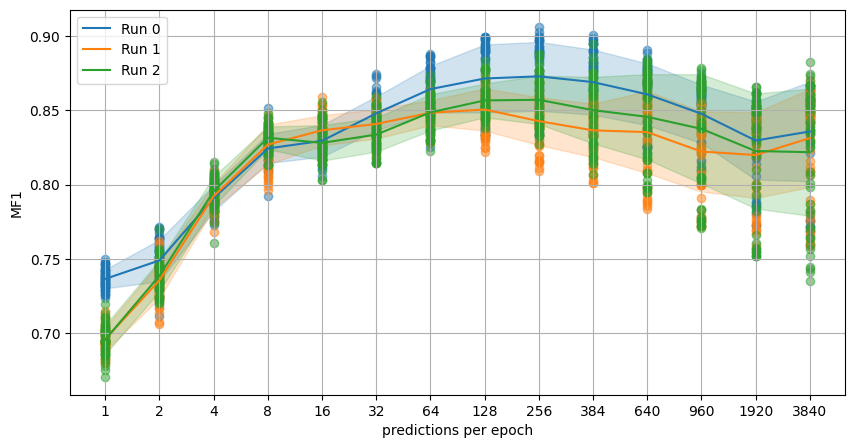

In [6]:
plt.figure(figsize=(10, 5))

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"]
for i, (model_run, mf1_scores_epoch) in enumerate(mf1_scores.items()):
    c = colors[i % len(colors)]
    means_to_plot = np.array(list(mf1_scores_epoch.values())).mean(axis=1)
    stds_to_plot = np.array(list(mf1_scores_epoch.values())).std(axis=1)
    plt.plot(range(len(mf1_scores_epoch)), means_to_plot, label=f"Run {i}", color=c)
    plt.fill_between(range(len(mf1_scores_epoch)), means_to_plot - stds_to_plot, means_to_plot + stds_to_plot,
                     alpha=0.2, color=c)
    plt.scatter(np.repeat(range(len(mf1_scores_epoch)), n_exps), np.array(list(mf1_scores_epoch.values())).flatten(),
                alpha=0.5, color=c)

first_key = next(iter(mf1_scores))
plt.xticks(range(len(mf1_scores[first_key])), list(mf1_scores[first_key].keys()))
plt.grid()
plt.xlabel("predictions per epoch")
plt.ylabel("MF1")
plt.legend()
plt.show()